# EVOLVE – Model Training (YOLOv8s)

This notebook trains and evaluates YOLOv8s object detection models on the EVOLVE dataset.

The objective is to assess the impact of transfer learning under extreme low-light and high-density concert environments.

This notebook performs:

1. Dataset verification
2. Training of two models under identical conditions:
   - COCO-pretrained initialization
   - Random initialization (from scratch)
3. Controlled validation-based comparison
4. Selection and export of the best-performing model
5. Export of training metadata

The test set is strictly excluded from this notebook and will be used only in Notebook 2.

## Experimental Setup

In [13]:
# ==============================
# Imports
# ==============================

import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
from ultralytics import YOLO


# ==============================
# Reproducibility
# ==============================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# If CUDA is available, also seed CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Make algorithms more deterministic where possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [14]:
# ==============================
# Device configuration
# ==============================

device = "cpu"

print("Device used:", device)
print("PyTorch version:", torch.__version__)

Device used: cpu
PyTorch version: 2.10.0


In [15]:
# ==============================
# Dataset configuration
# ==============================

DATASET_CONFIG_PATH = Path("../configs/dataset.yaml").resolve()

with open(DATASET_CONFIG_PATH, "r") as f:
    dataset_config = yaml.safe_load(f)

PROJECT_ROOT = Path("..").resolve()
BASE_PATH = (PROJECT_ROOT / dataset_config["path"]).resolve()

train_path = BASE_PATH / dataset_config["train"]
val_path = BASE_PATH / dataset_config["val"]

print("Dataset root:", BASE_PATH)
print("Train directory:", train_path)
print("Validation directory:", val_path)

# Check existence
assert train_path.exists(), "Train directory does not exist."
assert val_path.exists(), "Validation directory does not exist."

# Class names
class_names = dataset_config["names"]

if isinstance(class_names, dict):
    class_names = list(class_names.values())

print("Number of classes:", len(class_names))
print("Class names:", class_names)

Dataset root: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo
Train directory: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo/images/train
Validation directory: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo/images/val
Number of classes: 6
Class names: ['amp', 'guitar', 'drums', 'micro', 'mosh_pit', 'hands_raised']


In [16]:
# ==============================
# Dataset volume verification
# ==============================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

train_images = [
    p for p in train_path.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

val_images = [
    p for p in val_path.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

print("Number of training images:", len(train_images))
print("Number of validation images:", len(val_images))

Number of training images: 525
Number of validation images: 25


In [17]:
# ==============================
# Class distribution analysis (training set)
# ==============================

from collections import defaultdict

label_train_path = BASE_PATH / "labels" / "train"
assert label_train_path.exists(), "Training label directory does not exist."

class_counts = defaultdict(int)

label_files = list(label_train_path.glob("*.txt"))

for label_file in label_files:
    with open(label_file, "r") as f:
        for line in f:
            if line.strip():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

# Ensure all classes appear (even if count = 0)
distribution = {}

for class_id, class_name in enumerate(class_names):
    distribution[class_name] = class_counts.get(class_id, 0)

print("Class distribution (training set):")
for k, v in distribution.items():
    print(f"{k}: {v}")

Class distribution (training set):
amp: 592
guitar: 375
drums: 255
micro: 253
mosh_pit: 83
hands_raised: 527


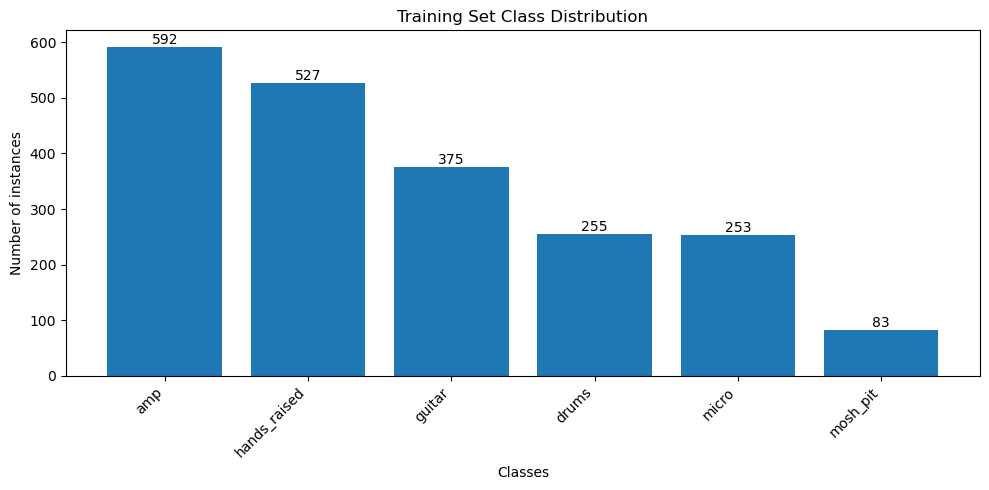

In [18]:
# ==============================
# Class distribution visualization
# ==============================

import matplotlib.pyplot as plt

# Sort classes by descending frequency (more informative)
sorted_items = sorted(distribution.items(), key=lambda x: x[1], reverse=True)

classes = [k for k, _ in sorted_items]
counts = [v for _, v in sorted_items]

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, counts)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Classes")
plt.ylabel("Number of instances")
plt.title("Training Set Class Distribution")

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# Save figure for report
os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/class_distribution.png")

plt.show()

## Baseline Evaluation

In [19]:
# ==========================================
# Experimental Configuration
# ==========================================

"""
Common experimental setup for transfer learning comparison.

Two training regimes:
1) COCO-pretrained fine-tuning
2) Random initialization (from scratch)

Both runs use identical hyperparameters to ensure
a controlled and fair comparison.
"""

EPOCHS = 50
IMGSZ = 640
BATCH_SIZE = 16
PATIENCE = 20

PROJECT_DIR = Path("../runs/train").resolve()

print("Experimental configuration loaded.")

Experimental configuration loaded.


In [20]:
from pathlib import Path
import yaml

DATASET_CONFIG_PATH = Path("../configs/dataset.yaml").resolve()

with open(DATASET_CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

base = Path(cfg["path"])
for split in ["train", "val", "test"]:
    img_dir = base / cfg[split]
    lbl_dir = base / "labels" / split
    print(split, "images:", img_dir, "exists:", img_dir.exists())
    print(split, "labels:", lbl_dir, "exists:", lbl_dir.exists())

train images: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo/images/train exists: True
train labels: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo/labels/train exists: True
val images: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo/images/val exists: True
val labels: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo/labels/val exists: True
test images: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo/images/test exists: True
test labels: /Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/data/processed/yolo/labels/test exists: True


In [ ]:
# ==========================================
# Training Regime 1 - Pretrained (COCO)
# ==========================================

"""
Transfer learning experiment.

The model is initialized with COCO-pretrained weights (yolov8s.pt)
and fine-tuned on the EVOLVE dataset.

This setup evaluates the impact of generic visual pretraining
under extreme concert conditions.
"""

model_pretrained = YOLO("yolov8s.pt")

results_pretrained = model_pretrained.train(
    data=DATASET_CONFIG_PATH,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    seed=SEED,
    patience=PATIENCE,
    device=device,
    workers=2,
    project=PROJECT_DIR,
    name="evolve_yolov8s_pretrained",
    exist_ok=True
)

print("Pretrained training completed.")

Ultralytics 8.4.19 🚀 Python-3.11.14 torch-2.10.0 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rinarazafimahefa/Documents/SISE/Computer_Vision/evolve/configs/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=evolve_yolov8s_pretrained, nbs=64, nms=False, opset=None, optimize=False, optimize

       1/50         0G      2.416      4.834      1.553         64        640: 100% ━━━━━━━━━━━━ 33/33 18.4s/it 10:0614.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 7.6s/it 7.6s
                   all         25         52      0.742      0.151      0.168     0.0866

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50         0G      2.165       2.81        1.4        124        640: 91% ━━━━━━━━━━╸─ 30/33 16.9s/it 8:56<50.8s

In [ ]:
# ==========================================
# Training Regime 2 - From Scratch
# ==========================================

"""
Learning without transfer.

The YOLOv8s architecture (yolov8s.yaml) is initialized
with random weights and trained exclusively on EVOLVE.

This experiment isolates the contribution of domain-specific
training without prior visual pretraining.
"""

model_scratch = YOLO("yolov8s.yaml")

results_scratch = model_scratch.train(
    data=DATASET_CONFIG_PATH,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    seed=SEED,
    patience=PATIENCE,
    device=device,
    workers=2,
    project=PROJECT_DIR,
    name="evolve_yolov8s_scratch",
    exist_ok=True
)

print("Scratch training completed.")

In [ ]:
# ==========================================
# Validation Comparison
# ==========================================

"""
Both models are evaluated on the validation split.

This ensures model selection remains unbiased with respect to
the held-out test set.

The same evaluation protocol is applied to both models.
"""

best_pretrained_path = results_pretrained.save_dir / "weights" / "best.pt"
best_scratch_path = results_scratch.save_dir / "weights" / "best.pt"

metrics_pretrained = YOLO(best_pretrained_path).val(
    data=DATASET_CONFIG_PATH,
    split="val",
    device=device
)

metrics_scratch = YOLO(best_scratch_path).val(
    data=DATASET_CONFIG_PATH,
    split="val",
    device=device
)

comparison = pd.DataFrame([
    {
        "Model": "Pretrained (COCO)",
        "mAP50-95": float(metrics_pretrained.box.map),
        "mAP50": float(metrics_pretrained.box.map50),
        "Precision": float(metrics_pretrained.box.mp),
        "Recall": float(metrics_pretrained.box.mr)
    },
    {
        "Model": "Scratch (Random Init)",
        "mAP50-95": float(metrics_scratch.box.map),
        "mAP50": float(metrics_scratch.box.map50),
        "Precision": float(metrics_scratch.box.mp),
        "Recall": float(metrics_scratch.box.mr)
    }
])

# Compute delta (transfer learning gain)
delta = comparison.iloc[0, 1:] - comparison.iloc[1, 1:]

print("Validation comparison:")
display(comparison)

print("\nTransfer Learning Gain (Pretrained - Scratch):")
display(delta)

In [ ]:
# ==========================================
# Transfer Learning Gain
# ==========================================

"""
Compute metric differences between pretrained and scratch models.

Positive values indicate improvement due to transfer learning.
"""

metric_cols = ["mAP50-95", "mAP50", "Precision", "Recall"]

cmp = comparison.set_index("Model")[metric_cols]

delta = cmp.loc["Pretrained (COCO)"] - cmp.loc["Scratch (Random Init)"]

print("Transfer learning gain (Pretrained - Scratch):")
display(delta.to_frame(name="delta"))

In [ ]:
# Simple verdict (based on mAP50-95)
if delta["mAP50-95"] > 0:
    print("✅ Transfer learning helps on EVOLVE (higher mAP50-95).")
elif delta["mAP50-95"] < 0:
    print("⚠️ Scratch is better on EVOLVE (possible domain mismatch with COCO).")
else:
    print("➖ No difference on mAP50-95.")

In [ ]:
# ==========================================
# Export Baseline Comparison
# ==========================================

"""
Export results for reproducibility and reporting.
- CSV: human-readable table
- JSON: full metadata + metrics snapshot
"""

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Save comparison table
csv_path = results_dir / "baseline_pretrained_vs_scratch.csv"
comparison.to_csv(csv_path, index=False)

# Build metadata payload (portable + informative)
payload = {
    "seed": SEED,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch_size": BATCH_SIZE,
    "patience": PATIENCE,
    "dataset_config_path": DATASET_CONFIG_PATH,
    "runs": {
        "pretrained_save_dir": str(results_pretrained.save_dir),
        "scratch_save_dir": str(results_scratch.save_dir),
        "pretrained_best_weights": str(best_pretrained_path),
        "scratch_best_weights": str(best_scratch_path),
    },
    "metrics_table": comparison.to_dict(orient="records"),
    "delta": delta.to_dict(),  # assumes you computed delta in the previous cell
    "env": {
        "torch_version": getattr(torch, "__version__", None),
        "ultralytics_version": getattr(__import__("ultralytics"), "__version__", None),
        "device": device if "device" in globals() else None
    }
}

json_path = results_dir / "baseline_pretrained_vs_scratch.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Baseline comparison exported successfully:")
print(" -", csv_path)
print(" -", json_path)

In [ ]:
# ==============================
# Load training logs (both regimes)
# ==============================

log_pretrained_path = results_pretrained.save_dir / "results.csv"
log_scratch_path = results_scratch.save_dir / "results.csv"

training_log_pretrained = pd.read_csv(log_pretrained_path)
training_log_scratch = pd.read_csv(log_scratch_path)

print("Pretrained log loaded from:", log_pretrained_path)
print("Scratch log loaded from:", log_scratch_path)

training_log_pretrained.head()

In [ ]:
# ==============================
# Validation Box Loss Comparison
# ==============================

plt.figure(figsize=(8, 5))

plt.plot(
    training_log_pretrained["epoch"],
    training_log_pretrained["val/box_loss"],
    label="Pretrained (COCO)"
)

plt.plot(
    training_log_scratch["epoch"],
    training_log_scratch["val/box_loss"],
    label="Scratch (Random Init)"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Box Loss")
plt.title("Validation Box Loss Comparison")
plt.legend()
plt.tight_layout()

plt.savefig("../results/figures/val_box_loss_comparison.png")
plt.show()

In [ ]:
# ==============================
# Validation mAP Curves Comparison
# ==============================

plt.figure(figsize=(8, 5))

# mAP@0.5
plt.plot(
    training_log_pretrained["epoch"],
    training_log_pretrained["metrics/mAP50"],
    label="Pretrained mAP@0.5"
)
plt.plot(
    training_log_scratch["epoch"],
    training_log_scratch["metrics/mAP50"],
    label="Scratch mAP@0.5"
)

plt.xlabel("Epoch")
plt.ylabel("mAP@0.5")
plt.title("Validation mAP@0.5 – Pretrained vs Scratch")
plt.legend()
plt.tight_layout()

Path("../results/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/map50_comparison.png")
plt.show()

In [ ]:
# ==============================
# Validation mAP50-95 Curves Comparison
# ==============================

plt.figure(figsize=(8, 5))

plt.plot(
    training_log_pretrained["epoch"],
    training_log_pretrained["metrics/mAP50-95"],
    label="Pretrained mAP@0.5:0.95"
)
plt.plot(
    training_log_scratch["epoch"],
    training_log_scratch["metrics/mAP50-95"],
    label="Scratch mAP@0.5:0.95"
)

plt.xlabel("Epoch")
plt.ylabel("mAP@0.5:0.95")
plt.title("Validation mAP@0.5:0.95 – Pretrained vs Scratch")
plt.legend()
plt.tight_layout()

plt.savefig("../results/figures/map50_95_comparison.png")
plt.show()

## Exports

In [ ]:
# ==========================================
# Export metrics (pretrained vs scratch)
# ==========================================

from pathlib import Path
import json

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Main comparison table
comparison.to_csv(results_dir / "pretrained_vs_scratch_metrics.csv", index=False)

# Transfer gain (delta)
delta.to_csv(results_dir / "pretrained_vs_scratch_delta.csv")

payload = {
    "seed": SEED,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch_size": BATCH_SIZE,
    "patience": PATIENCE,
    "best_pretrained_path": str(best_pretrained_path),
    "best_scratch_path": str(best_scratch_path),
    "metrics": comparison.to_dict(orient="records"),
    "delta": delta.to_dict()
}

with open(results_dir / "pretrained_vs_scratch_metrics.json", "w") as f:
    json.dump(payload, f, indent=4)

print("Exported pretrained vs scratch metrics.")

In [ ]:
# ==========================================
# Export best weights
# ==========================================

import shutil

shutil.copy(best_pretrained_path, results_dir / "best_pretrained.pt")
shutil.copy(best_scratch_path, results_dir / "best_scratch.pt")

print("Exported best_pretrained.pt and best_scratch.pt")

In [ ]:
# ==========================================
# Export training metadata
# ==========================================

training_metadata = {
    "model_architecture": "yolov8s",
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "patience": PATIENCE,
    "train_images": len(train_images),
    "val_images": len(val_images),
    "runs": {
        "pretrained_run_dir": str(results_pretrained.save_dir),
        "scratch_run_dir": str(results_scratch.save_dir),
    }
}

with open(results_dir / "training_config.json", "w") as f:
    json.dump(training_metadata, f, indent=4)

print("Training configuration exported.")

## Conclusion

This notebook implemented a controlled comparison between two training regimes on the EVOLVE dataset:

- YOLOv8s initialized with COCO-pretrained weights (transfer learning)
- YOLOv8s trained from scratch (random initialization)

Both models were trained under identical hyperparameters and evaluated on the same validation split.

The comparison highlights the impact of transfer learning under extreme low-light and high-density concert conditions.

The best-performing model, selected based on validation metrics, will now be evaluated on the strictly held-out test set in Notebook 2.